In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import KNNImputer
from xgboost import XGBRegressor

In [2]:
#Load data
df = pd.read_csv("gw_sanity.csv")
print(f"Original dataset shape: {df.shape}")

Original dataset shape: (42, 20)


In [3]:
#COMPUTE WQI- BIS STANDARDS
param_map = {
    'ph': 'ph',
    'turbidity': 'turbidity',
    'chloride': 'chloride_(ppm)',
    'sulphate': 'sulphates(ppm)',
    'nitrate': 'nitrate(ppm)',
    'iron': 'iron_(ppm)',
    'fluoride': 'fluorides(ppm)',
    'conductivity': 'conductivity'
}

def compute_bis_wqi(df):
    bis_limits = {
        "ph": (6.5, 8.5),
        "turbidity": 5,
        "chloride": 250,
        "sulphate": 200,
        "nitrate": 45,
        "fluoride": 1.5,
        "iron": 0.3,
        "conductivity": 2000
    }
    weights = {k: 1/v if not isinstance(v, tuple) else 1/v[1]
               for k, v in bis_limits.items()}
    wqi_vals = []
    for _, row in df.iterrows():
        num, den = 0, 0
        for p, limit in bis_limits.items():
            col = param_map[p]
            if col not in df.columns or pd.isna(row[col]):
                continue
            wi = weights[p]
            if p == 'ph':
                qi = abs(row[col] - 7.0) / (8.5 - 7.0) * 100
            else:
                qi = (row[col] / limit) * 100
            num += wi * qi
            den += wi
        wqi_vals.append(num / den if den != 0 else np.nan)
    df = df.copy()
    df["wqi"] = wqi_vals
    return df

df = compute_bis_wqi(df)
print(f"WQI computed. NaN in WQI: {df['wqi'].isna().sum()}")

WQI computed. NaN in WQI: 0


In [18]:
#DROP USELESS OR HIGH LEAKAGE COLUMNS
## Columns with 100% NaN → no information
always_nan_cols = [col for col in df.columns if df[col].isna().all()]
print(f"Dropping always-NaN columns: {always_nan_cols}")
df.drop(columns=always_nan_cols, inplace=True)

# iron_(ppm) has ~1.0 correlation with WQI — it IS part of the WQI formula
# Keeping it causes data leakage; the model learns a trivial mapping.
# Drop it so the model learns from real predictors.
if 'iron_(ppm)' in df.columns:
    print("Dropping 'iron_(ppm)' — near-perfect leakage feature (corr=0.9997 with WQI)")
    df.drop(columns=['iron_(ppm)'], inplace=True)

Dropping always-NaN columns: []


In [7]:
#FEATURE/TARGET SPLIT
X = df.select_dtypes(include="number").drop(columns=["wqi"])
y = df["wqi"].dropna()
X = X.loc[y.index]  # align after dropna

print(f"\nFeatures used: {list(X.columns)}")
print(f"Dataset size before augmentation: {X.shape}")
print(f"\nMissing values per feature:\n{X.isna().sum()}")


Features used: ['year', 'ph', 'turbidity', 'conductivity', 'chloride_(ppm)', 'sulphates(ppm)', 'cod(ppm)', 'bod(ppm)', 'do(ppm)', 'ammonia(ppm)', 'nitrate(ppm)', 'fluorides(ppm)', 'phosphates(ppm)', 'total_bacterial_count_(cfu/ml)', 'total_fungal_count_(cfu/ml)']
Dataset size before augmentation: (42, 15)

Missing values per feature:
year                               0
ph                                 0
turbidity                          0
conductivity                       0
chloride_(ppm)                     0
sulphates(ppm)                     0
cod(ppm)                           0
bod(ppm)                           0
do(ppm)                            0
ammonia(ppm)                       0
nitrate(ppm)                       0
fluorides(ppm)                    27
phosphates(ppm)                   36
total_bacterial_count_(cfu/ml)     0
total_fungal_count_(cfu/ml)       18
dtype: int64



After augmentation: (168, 15) (was (42, 15))


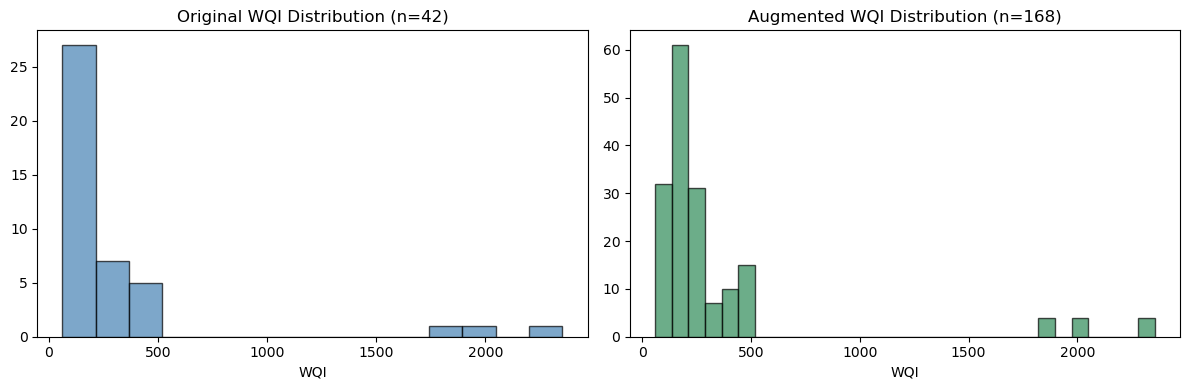

Saved: wqi_distribution.png


In [8]:
#DATA AUGMENTATION - KEY IMPROVEMENT
# Strategy: Gaussian noise injection on numeric features
# - Preserves statistical distribution
# - Noise scale = 1% of each feature's std (conservative, physically plausible)
# - Augment 3x to get ~168 rows from 42

def augment_data(X, y, n_copies=3, noise_fraction=0.01, random_state=42):
    """
    For each original sample, create n_copies noisy copies.
    Noise = Gaussian with std = noise_fraction * feature_std.
    Handles NaN by only adding noise to non-NaN values.
    """
    rng = np.random.RandomState(random_state)
    feature_stds = X.std(skipna=True)

    X_aug_list = [X.copy()]
    y_aug_list = [y.copy()]

    for i in range(n_copies):
        X_noisy = X.copy()
        for col in X.columns:
            std = feature_stds[col]
            if std == 0 or np.isnan(std):
                continue
            noise = rng.normal(0, noise_fraction * std, size=len(X))
            # Only add noise where value is not NaN
            mask = X_noisy[col].notna()
            X_noisy.loc[mask, col] = X_noisy.loc[mask, col] + noise[mask]
        # Small noise on y too (0.5% of std)
        y_noise = rng.normal(0, 0.005 * y.std(), size=len(y))
        X_aug_list.append(X_noisy)
        y_aug_list.append(y + y_noise)

    X_aug = pd.concat(X_aug_list, ignore_index=True)
    y_aug = pd.concat(y_aug_list, ignore_index=True)
    return X_aug, y_aug

X_aug, y_aug = augment_data(X, y, n_copies=3, noise_fraction=0.01)
print(f"\nAfter augmentation: {X_aug.shape} (was {X.shape})")

# EDA: WQI Distribution after augmentation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title("Original WQI Distribution (n=42)")
axes[0].set_xlabel("WQI")
axes[1].hist(y_aug, bins=30, edgecolor='black', alpha=0.7, color='seagreen')
axes[1].set_title(f"Augmented WQI Distribution (n={len(y_aug)})")
axes[1].set_xlabel("WQI")
plt.tight_layout()
plt.savefig("wqi_distribution.png", dpi=150)
plt.show()
print("Saved: wqi_distribution.png")

In [9]:
#TRAIN TEST SPLIT ON AUGMENTED DATA
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (134, 15), Test size: (34, 15)


In [10]:
#IMPUTATION (KNN — better for correlated water params)
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

In [11]:
#SCALING
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc = scaler.transform(X_test_imp)

In [12]:
#NSE METRIC
def nse(y_true, y_pred):
    """Nash-Sutcliffe Efficiency — widely used in hydrological modeling"""
    return 1 - (
        np.sum((np.array(y_true) - np.array(y_pred)) ** 2) /
        np.sum((np.array(y_true) - np.mean(y_true)) ** 2)
    )

In [13]:
#HYPERPARAMETER TUNING- (GridSearchCV)

print("\n--- Hyperparameter Tuning ---")

param_grids = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42, verbosity=0),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5, 7]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "C": [1, 10, 100],
            "gamma": ["scale", "auto", 0.1],
            "kernel": ["rbf", "linear"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [None, 3, 5, 10],
            "min_samples_split": [2, 5, 10]
        }
    }
}

best_models = {}
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

final_results = []

for name, cfg in param_grids.items():
    grid = GridSearchCV(cfg["model"], cfg["params"], cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_train_sc, y_train)
    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_sc)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    nse_val = nse(y_test, y_pred)

    cv5 = cross_val_score(best_model, X_train_sc, y_train, cv=kf5, scoring="r2")
    cv10 = cross_val_score(best_model, X_train_sc, y_train, cv=kf10, scoring="r2")

    print(f"{name}: R²={r2:.3f} | Best params: {grid.best_params_}")

    final_results.append([
        name, round(r2, 4), round(rmse, 4), round(mae, 4), round(nse_val, 4),
        f"{cv5.mean():.3f} ± {cv5.std():.3f}",
        f"{cv10.mean():.3f} ± {cv10.std():.3f}"
    ])


--- Hyperparameter Tuning ---
Random Forest: R²=0.999 | Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Gradient Boosting: R²=1.000 | Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
XGBoost: R²=0.989 | Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 50}
SVR: R²=0.856 | Best params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Decision Tree: R²=1.000 | Best params: {'max_depth': 10, 'min_samples_split': 2}


In [14]:
#RESULTS TABLE
columns = ["Model", "R²", "RMSE", "MAE", "NSE", "5-Fold CV R²", "10-Fold CV R²"]
results_df = pd.DataFrame(final_results, columns=columns)
results_df = results_df.sort_values(by="R²", ascending=False).reset_index(drop=True)

print("\n=== FINAL MODEL COMPARISON ===")
print(results_df.to_string(index=False))


=== FINAL MODEL COMPARISON ===
            Model     R²     RMSE     MAE    NSE  5-Fold CV R² 10-Fold CV R²
    Decision Tree 0.9999   2.4487  1.9279 0.9999 0.992 ± 0.008 1.000 ± 0.000
Gradient Boosting 0.9998   4.1461  3.3648 0.9998 0.985 ± 0.029 0.999 ± 0.001
    Random Forest 0.9990   9.4855  7.0084 0.9990 0.986 ± 0.020 0.996 ± 0.006
          XGBoost 0.9894  30.9896 24.4996 0.9894 0.797 ± 0.371 0.909 ± 0.197
              SVR 0.8563 114.3073 25.0833 0.8563 0.598 ± 0.112 0.704 ± 0.166


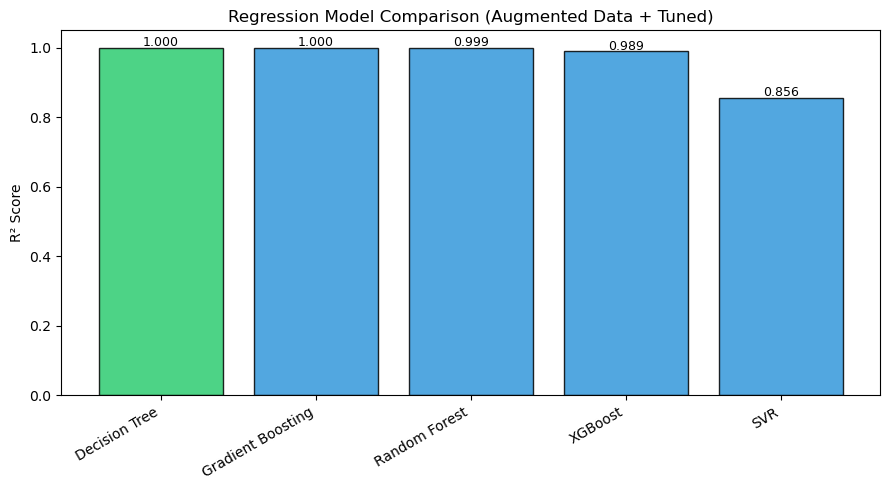

Saved: model_comparison.png


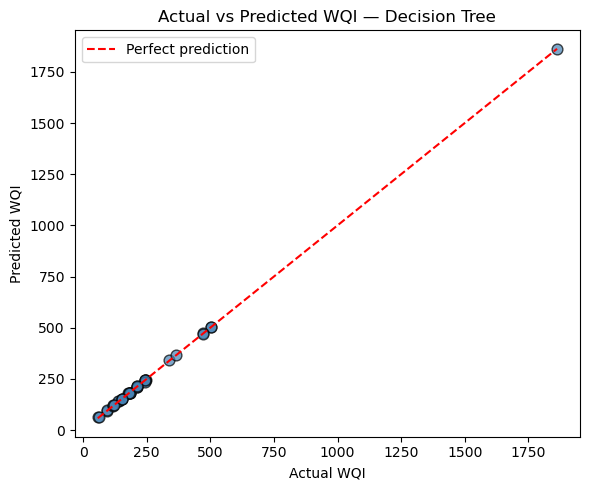

Saved: actual_vs_predicted.png


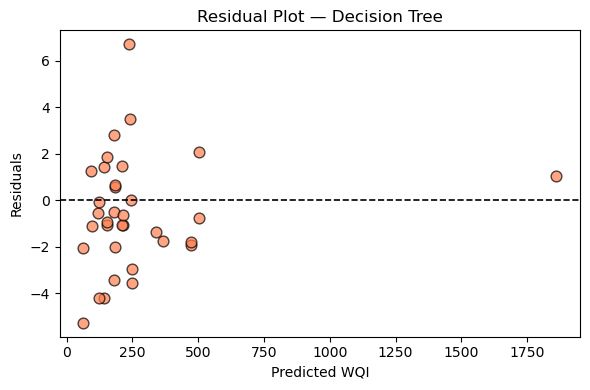

Saved: residuals.png


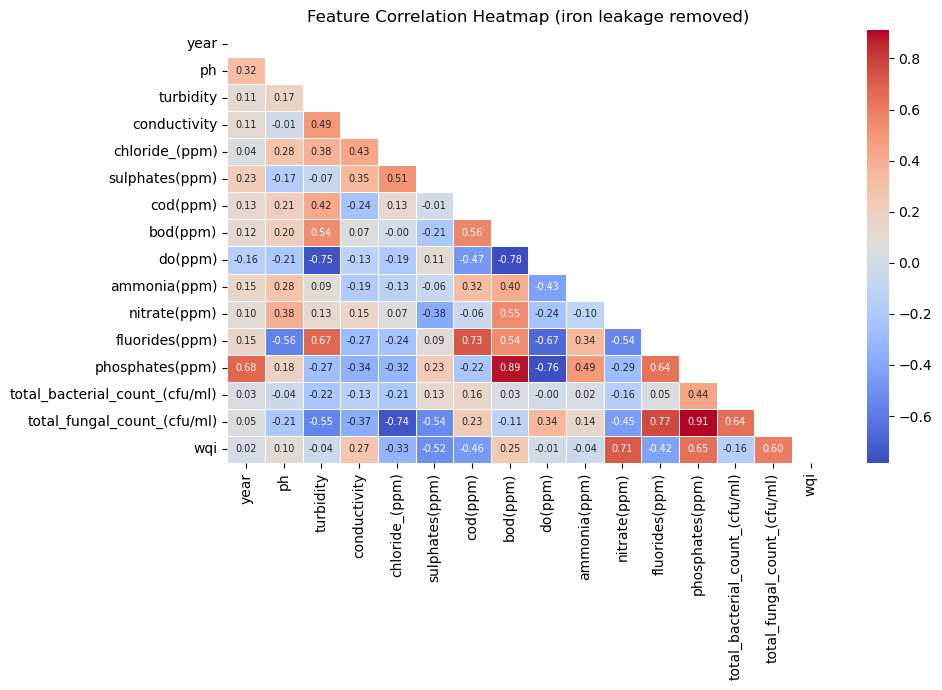

Saved: correlation_heatmap.png


In [17]:
#PLOTS

# Model comparison bar chart
plt.figure(figsize=(9, 5))
colors = ['#2ecc71' if r == results_df['R²'].max() else '#3498db' for r in results_df['R²']]
bars = plt.bar(results_df["Model"], results_df["R²"], color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, results_df['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.ylabel("R² Score")
plt.title("Regression Model Comparison (Augmented Data + Tuned)")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")

# Actual vs Predicted (best model)
best_name = results_df.iloc[0]["Model"]
best_model = best_models[best_name]
y_pred_best = best_model.predict(X_test_sc)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_best, alpha=0.7, color='steelblue', edgecolors='black', s=60)
lims = [min(y_test.min(), y_pred_best.min()) - 1, max(y_test.max(), y_pred_best.max()) + 1]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual WQI")
plt.ylabel("Predicted WQI")
plt.title(f"Actual vs Predicted WQI — {best_name}")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved: actual_vs_predicted.png")

# Residual plot
residuals = np.array(y_test) - y_pred_best
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_best, residuals, alpha=0.7, color='coral', edgecolors='black', s=60)
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.xlabel("Predicted WQI")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {best_name}")
plt.tight_layout()
plt.savefig("residuals.png", dpi=150)
plt.show()
print("Saved: residuals.png")

# Correlation heatmap (no leaky features)
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            annot_kws={"size": 7}, linewidths=0.4)
plt.title("Feature Correlation Heatmap (iron leakage removed)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

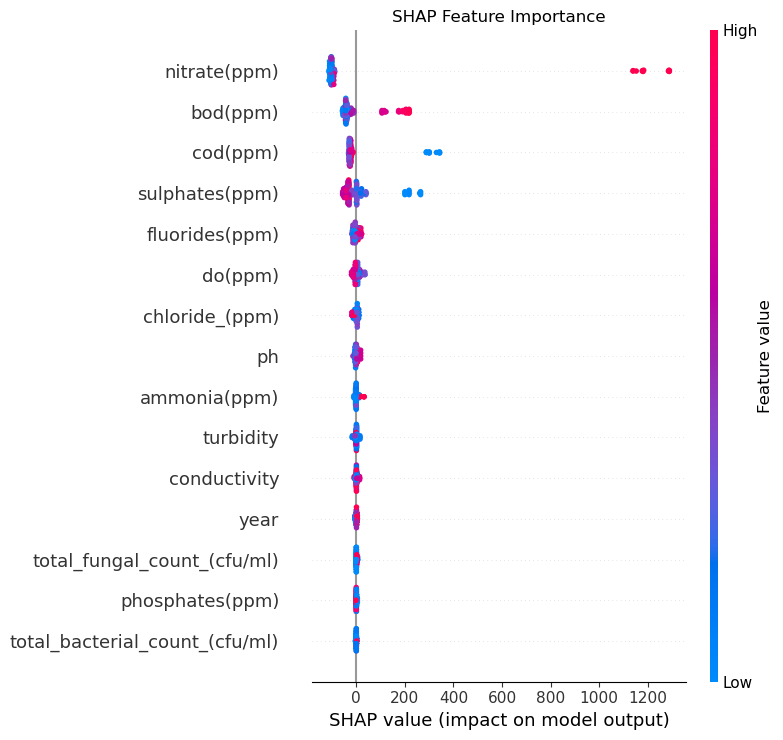

Saved: shap_summary.png

 Done! Best model: Decision Tree
Model            Decision Tree
R²                      0.9999
RMSE                    2.4487
MAE                     1.9279
NSE                     0.9999
5-Fold CV R²     0.992 ± 0.008
10-Fold CV R²    1.000 ± 0.000
Name: 0, dtype: object


In [16]:
#SHAP ANALYSIS
try:
    import shap
    # Use RF or GB for SHAP TreeExplainer
    shap_model_name = "Random Forest" if "Random Forest" in best_models else best_name
    shap_model = best_models[shap_model_name]

    # Retrain if it's SVR (not supported by TreeExplainer)
    if not hasattr(shap_model, 'estimators_') and not hasattr(shap_model, 'estimators'):
        print(f"Best model is {best_name} — using Random Forest for SHAP")
        shap_model = best_models.get("Random Forest",
                     RandomForestRegressor(random_state=42).fit(X_train_sc, y_train))

    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_train_sc)

    feature_names = list(X.columns)
    plt.figure()
    shap.summary_plot(shap_values, X_train_sc, feature_names=feature_names, show=False)
    plt.title("SHAP Feature Importance")
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_summary.png")
except ImportError:
    print("SHAP not installed. Run: pip install shap")

print("\n Done! Best model:", best_name)
print(results_df.iloc[0])

In [24]:
import os
print(os.getcwd())  # should show the folder where wqi_map_module.py lives

C:\Users\jaswa\Downloads\Py-DS-ML-Bootcamp-master


 Interactive map saved: gw_regression_map.html  (open in browser)
🔴 Most affected:   Markanda River(Site 1) (Ground Water), Ghaggar River(Site 4) (Ground Water), Ghaggar River(Site 5) (Ground Water)
🟢 Least affected:  Agra Canal(Site 1) (Ground Water), Ghaggar River(Site 3) (Ground Water), Yamuna River(Site 4) (Ground Water)


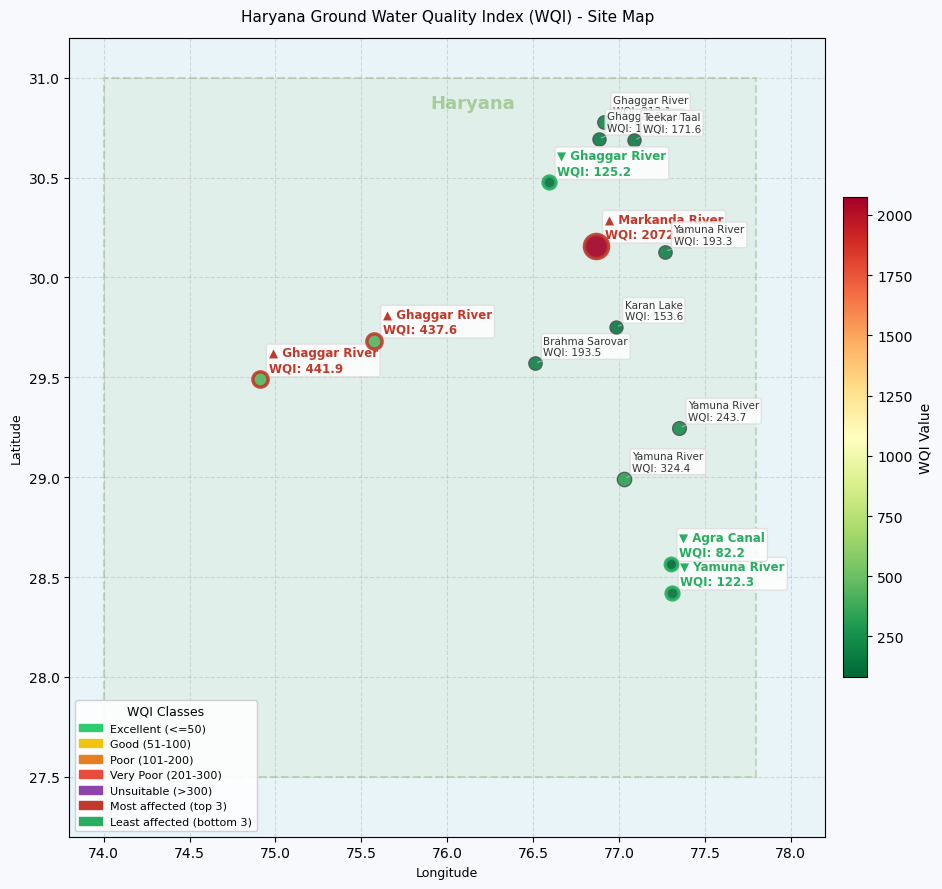

 Static map saved: gw_regression_map.png


In [27]:
# MAP VISUALIZATION — embedded directly 

import pandas as pd
import numpy as np
 
def dms_to_dec(deg, mins, secs, direction):
    dec = float(deg) + float(mins)/60 + float(secs)/3600
    if direction in ['S', 'W']:
        dec = -dec
    return round(dec, 6)
 
SITE_COORDS = {
    "Ghaggar River(Site 1) (Ground Water)":   (dms_to_dec(30,46,35,'N'), dms_to_dec(76,54,51,'E')),
    "Ghaggar River(Site 2) (Ground Water)":   (dms_to_dec(30,41,37,'N'), dms_to_dec(76,52,52,'E')),
    "Ghaggar River(Site 3) (Ground Water)":   (30.4762, 76.5906),
    "Ghaggar River(Site 4) (Ground Water)":   (dms_to_dec(29,41,1,'N'), dms_to_dec(75,34,33,'E')),
    "Ghaggar River(Site 5) (Ground Water)":   (dms_to_dec(29,29,21,'N'), dms_to_dec(74,54,38,'E')),
    "Yamuna River(Site 1) (Ground Water)":    (30.1290, 77.2674),
    "Yamuna River(Site 2) (Ground Water)":    (dms_to_dec(29,14,48,'N'), dms_to_dec(77,21,5,'E')),
    "Yamuna River(Site 3) (Ground Water)":    (28.993,  77.027),
    "Yamuna River(Site 4) (Ground Water)":    (28.4215, 77.3076),
    "Markanda River(Site 1) (Ground Water)":  (30.1585, 76.8677),
    "Agra Canal(Site 1) (Ground Water)":      (dms_to_dec(28,33,56,'N'), dms_to_dec(77,17,60,'E')),
    "Teekar Taal(Site 3) (Ground Water)":     (30.6873, 77.0878),
    "Karan Lake (Site 1) (Ground Water)":     (dms_to_dec(29,44,62,'N'), dms_to_dec(76,58,58,'E')),
    "Brahma Sarovar(Site 2) (Ground Water)":  (29.57,   76.51),
}
CLASS_COLORS = {
    "Excellent": "#2ecc71", "Good": "#f1c40f",
    "Poor": "#e67e22",      "Very Poor": "#e74c3c", "Unsuitable": "#8e44ad",
}
 
def get_class_color(wqi_class):
    if pd.isna(wqi_class): return "#95a5a6"
    for key in CLASS_COLORS:
        if key.lower() in str(wqi_class).lower(): return CLASS_COLORS[key]
    return "#95a5a6"
 
def match_site(site_name, water_type):
    site_lower = str(site_name).lower().strip()
    best_match, best_score = None, 0
    for key in SITE_COORDS:
        key_lower = key.lower()
        wt_tag = "ground water" if water_type == "ground" else "surface water"
        if wt_tag not in key_lower: continue
        key_words  = set(key_lower.replace("(","").replace(")","").split())
        site_words = set(site_lower.replace("(","").replace(")","").split())
        score = len(key_words & site_words)
        if score > best_score:
            best_score = score
            best_match = key
    return (SITE_COORDS[best_match], best_match) if best_score >= 2 else (None, None)
 
def plot_wqi_map(df, wqi_col="wqi", class_col="wqi_class",
                 water_type="ground", top_n=3, save_path="wqi_map.html"):
    try:
        import folium
    except ImportError:
        print("Run: pip install folium"); return
    site_col = next((c for c in ["site","Site","SITE"] if c in df.columns), None)
    if not site_col: print("No site column found."); return
    agg = {wqi_col: "mean"}
    if class_col in df.columns:
        agg[class_col] = lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
    sdf = df.groupby(site_col).agg(agg).reset_index()
    sdf.columns = ["site","wqi_mean"] + (["wqi_class"] if class_col in df.columns else [])
    lats,lons = [],[]
    for s in sdf["site"]:
        coords,_ = match_site(s, water_type)
        lats.append(coords[0] if coords else None)
        lons.append(coords[1] if coords else None)
    sdf["lat"],sdf["lon"] = lats,lons
    sdf = sdf.dropna(subset=["lat","lon"])
    if sdf.empty: print("No matched coordinates."); return
    sdf = sdf.sort_values("wqi_mean",ascending=False).reset_index(drop=True)
    most_aff  = set(sdf.head(top_n)["site"])
    least_aff = set(sdf.tail(top_n)["site"])
    wmin,wmax = sdf["wqi_mean"].min(), sdf["wqi_mean"].max()
    m = folium.Map(location=[sdf["lat"].mean(), sdf["lon"].mean()],
                   zoom_start=7, tiles="CartoDB positron")
    water_label = "Ground Water" if water_type=="ground" else "Surface Water"
    m.get_root().html.add_child(folium.Element(
        f'<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);'
        f'z-index:1000;background:white;padding:8px 18px;border-radius:8px;'
        f'border:1px solid #ccc;font-size:15px;font-weight:bold;'
        f'box-shadow:2px 2px 6px rgba(0,0,0,.15);">'
        f'Haryana {water_label} Quality Index (WQI) Map</div>'
    ))
    legend = ('<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
              'background:white;padding:12px 16px;border-radius:8px;border:1px solid #ccc;'
              'font-size:13px;line-height:1.8;box-shadow:2px 2px 6px rgba(0,0,0,.15);">'
              '<b>WQI Classification</b><br>'
              '<span style="color:#2ecc71">&#9679;</span> Excellent (&le;50)<br>'
              '<span style="color:#f1c40f">&#9679;</span> Good (51-100)<br>'
              '<span style="color:#e67e22">&#9679;</span> Poor (101-200)<br>'
              '<span style="color:#e74c3c">&#9679;</span> Very Poor (201-300)<br>'
              '<span style="color:#8e44ad">&#9679;</span> Unsuitable (&gt;300)<br>'
              '<hr style="margin:6px 0">'
              f'&#11014; Most affected (Top {top_n})<br>'
              f'&#11015; Least affected (Bottom {top_n})</div>')
    m.get_root().html.add_child(folium.Element(legend))
    for _,row in sdf.iterrows():
        wv = row["wqi_mean"]
        wc = row.get("wqi_class","Unknown")
        sn = row["site"]
        color = get_class_color(wc)
        norm  = (wv-wmin)/(wmax-wmin+1e-9)
        radius = 8 + norm*14
        is_most  = sn in most_aff
        is_least = sn in least_aff
        bc = "#c0392b" if is_most else ("#27ae60" if is_least else "#555")
        bw = 3 if (is_most or is_least) else 1.5
        rank = " 🔴 MOST AFFECTED" if is_most else (" 🟢 LEAST AFFECTED" if is_least else "")
        popup_html = (f'<div style="font-family:Arial;font-size:13px;min-width:200px;">'
                      f'<b>{sn}</b>{rank}<br><hr style="margin:4px 0">'
                      f'<b>WQI:</b> {wv:.2f}<br>'
                      f'<b>Class:</b> <span style="color:{color};font-weight:bold">{wc}</span>'
                      f'</div>')
        folium.CircleMarker(location=[row["lat"],row["lon"]], radius=radius,
            color=bc, weight=bw, fill=True, fill_color=color, fill_opacity=0.85,
            popup=folium.Popup(popup_html, max_width=260),
            tooltip=f"{sn} | WQI: {wv:.1f} | {wc}").add_to(m)
        if is_most or is_least:
            arrow = "▲" if is_most else "▼"
            lc = "#c0392b" if is_most else "#27ae60"
            short = sn.split("(")[0].strip()
            folium.Marker(location=[row["lat"]+0.04, row["lon"]],
                icon=folium.DivIcon(
                    html=f'<div style="font-size:11px;font-weight:bold;color:{lc};white-space:nowrap;">{arrow} {short}</div>',
                    icon_size=(180,20), icon_anchor=(0,10))).add_to(m)
    # Side table
    rows_html = ""
    for _,row in sdf.iterrows():
        wc = row.get("wqi_class","—")
        flag = "🔴" if row["site"] in most_aff else ("🟢" if row["site"] in least_aff else "")
        short = str(row["site"]).split("(")[0].strip()
        rows_html += (f'<tr><td>{flag} {short}</td>'
                      f'<td style="text-align:center">{row["wqi_mean"]:.1f}</td>'
                      f'<td style="color:{get_class_color(wc)};font-weight:bold;text-align:center">{wc}</td></tr>')
    m.get_root().html.add_child(folium.Element(
        f'<div style="position:fixed;top:65px;right:15px;z-index:1000;background:white;'
        f'padding:10px 14px;border-radius:8px;border:1px solid #ccc;font-size:12px;'
        f'max-height:420px;overflow-y:auto;box-shadow:2px 2px 6px rgba(0,0,0,.15);">'
        f'<b>Site Rankings</b><br><br>'
        f'<table style="border-collapse:collapse;width:100%">'
        f'<tr style="border-bottom:1px solid #ddd;font-size:11px;color:#666">'
        f'<th style="text-align:left;padding:2px 6px">Site</th>'
        f'<th style="padding:2px 6px">WQI</th><th style="padding:2px 6px">Class</th></tr>'
        f'{rows_html}</table></div>'
    ))
    m.save(save_path)
    print(f" Interactive map saved: {save_path}  (open in browser)")
    print(f"🔴 Most affected:   {', '.join(most_aff)}")
    print(f"🟢 Least affected:  {', '.join(least_aff)}")
    return m
 
def plot_wqi_map_static(df, wqi_col="wqi", class_col="wqi_class",
                        water_type="ground", top_n=3, save_path="wqi_map_static.png"):
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable
    site_col = next((c for c in ["site","Site","SITE"] if c in df.columns), None)
    if not site_col: print("No site column found."); return
    agg = {wqi_col: "mean"}
    if class_col in df.columns:
        agg[class_col] = lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
    sdf = df.groupby(site_col).agg(agg).reset_index()
    sdf.columns = ["site","wqi_mean"] + (["wqi_class"] if class_col in df.columns else [])
    lats,lons = [],[]
    for s in sdf["site"]:
        coords,_ = match_site(s, water_type)
        lats.append(coords[0] if coords else None)
        lons.append(coords[1] if coords else None)
    sdf["lat"],sdf["lon"] = lats,lons
    sdf = sdf.dropna(subset=["lat","lon"])
    if sdf.empty: print("No matched coordinates."); return
    sdf = sdf.sort_values("wqi_mean",ascending=False).reset_index(drop=True)
    most_aff  = set(sdf.head(top_n)["site"])
    least_aff = set(sdf.tail(top_n)["site"])
    fig, ax = plt.subplots(figsize=(10,9))
    ax.set_facecolor("#e8f4f8"); fig.patch.set_facecolor("#f7f9fc")
    ax.add_patch(plt.Polygon([[74,27.5],[74,31],[77.8,31],[77.8,27.5]],
        closed=True, fill=True, facecolor="#d5e8d4", edgecolor="#82b366",
        linewidth=1.5, linestyle="--", alpha=0.4))
    ax.text(75.9, 30.85, "Haryana", fontsize=13, color="#82b366", fontweight='bold', alpha=0.6)
    norm = Normalize(vmin=sdf["wqi_mean"].min(), vmax=sdf["wqi_mean"].max())
    cmap = plt.cm.RdYlGn_r
    for _,row in sdf.iterrows():
        color = cmap(norm(row["wqi_mean"]))
        is_most  = row["site"] in most_aff
        is_least = row["site"] in least_aff
        ec = "#c0392b" if is_most else ("#27ae60" if is_least else "#555")
        lw = 2.5 if (is_most or is_least) else 1.0
        ax.scatter(row["lon"], row["lat"], s=80+norm(row["wqi_mean"])*220,
                   c=[color], edgecolors=ec, linewidths=lw,
                   zorder=5 if (is_most or is_least) else 3, alpha=0.9)
        short = str(row["site"]).split("(")[0].strip()
        prefix = "▲ " if is_most else ("▼ " if is_least else "")
        fc = "#c0392b" if is_most else ("#27ae60" if is_least else "#333")
        ax.annotate(f"{prefix}{short}\nWQI: {row['wqi_mean']:.1f}",
            xy=(row["lon"], row["lat"]),
            xytext=(row["lon"]+0.05, row["lat"]+0.04),
            fontsize=8.5 if (is_most or is_least) else 7.5,
            color=fc, fontweight="bold" if (is_most or is_least) else "normal",
            arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8),
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#ddd", alpha=0.85))
    sm = ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.6, pad=0.02).set_label("WQI Value", fontsize=10)
    legend_patches = [
        mpatches.Patch(color=CLASS_COLORS["Excellent"],  label="Excellent (<=50)"),
        mpatches.Patch(color=CLASS_COLORS["Good"],       label="Good (51-100)"),
        mpatches.Patch(color=CLASS_COLORS["Poor"],       label="Poor (101-200)"),
        mpatches.Patch(color=CLASS_COLORS["Very Poor"],  label="Very Poor (201-300)"),
        mpatches.Patch(color=CLASS_COLORS["Unsuitable"], label="Unsuitable (>300)"),
        mpatches.Patch(color="#c0392b", label=f"Most affected (top {top_n})"),
        mpatches.Patch(color="#27ae60", label=f"Least affected (bottom {top_n})"),
    ]
    ax.legend(handles=legend_patches, loc="lower left", fontsize=8,
              framealpha=0.9, title="WQI Classes", title_fontsize=9)
    water_label = "Ground Water" if water_type=="ground" else "Surface Water"
    ax.set_title(f"Haryana {water_label} Quality Index (WQI) - Site Map", fontsize=11, pad=12)
    ax.set_xlabel("Longitude",fontsize=9); ax.set_ylabel("Latitude",fontsize=9)
    ax.grid(True,linestyle="--",alpha=0.4,color="#aaa")
    ax.set_xlim(73.8,78.2); ax.set_ylim(27.2,31.2)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f" Static map saved: {save_path}")
 
# RUN MAP 
# Add wqi_class if not already present
if "wqi_class" not in df.columns:
    def wqi_class_label(w):
        if w<=50: return "Excellent"
        elif w<=100: return "Good"
        elif w<=200: return "Poor"
        elif w<=300: return "Very Poor"
        else: return "Unsuitable"
    df["wqi_class"] = df["wqi"].apply(wqi_class_label)
 
plot_wqi_map(df, wqi_col="wqi", class_col="wqi_class",
             water_type="ground", top_n=3, save_path="gw_regression_map.html")
plot_wqi_map_static(df, wqi_col="wqi", class_col="wqi_class",
                    water_type="ground", top_n=3, save_path="gw_regression_map.png")